# Análise Exploratória de Dados — Campanha de Marketing

**Objetivo:** Realizar uma análise exploratória multivariada para identificar os fatores que explicam por que um cliente aceita ou não uma campanha de marketing e quais produtos são mais consumidos.

**Dataset:** Dados de clientes com informações demográficas, gastos por categoria de produto, canal de compra e resposta a 6 campanhas de marketing distintas.

---

## 1. Configuração do Ambiente

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np
from datetime import datetime

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Estatística
from scipy.stats import shapiro, mannwhitneyu

# Machine Learning
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Configurações globais
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 14, 'axes.labelsize': 12})

In [2]:
import sklearn, scipy

print(f"pandas   : {pd.__version__}")
print(f"numpy    : {np.__version__}")
print(f"sklearn  : {sklearn.__version__}")
print(f"scipy    : {scipy.__version__}")

pandas   : 2.3.3
numpy    : 2.2.6
sklearn  : 1.7.2
scipy    : 1.15.3


---
## 2. Carregamento dos Dados

In [3]:
df = pd.read_csv("dataset.csv")

print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

Linhas: 2237 | Colunas: 25


,ID,Ano_Nascimento,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Data_Cadastro_Cliente,Gasto_Vinhos,Gasto_Frutas,...,Num_Compras_Web,Num_Compras_Catalogo,Num_Compras_Loja,Num_Visitas_Web_Mes,Aceitou_Campanha_1,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6
0,9970,1977,Graduação,Casado,"$55,375.00",0,1,10/17/13,42,11,...,1,1,6,2,0,0,0,0,0,0
1,4002,1960,PhD,Casado,"$77,037.00",0,1,10/13/13,463,96,...,7,7,12,3,0,0,0,0,0,0
2,10914,1970,Graduação,Solteiro,"$24,163.00",1,1,2010-12-13,4,1,...,1,0,3,4,0,0,0,0,0,0
3,7279,1969,PhD,Casado,"$69,476.00",0,0,9/30/13,260,86,...,4,6,4,2,0,0,0,0,0,0
4,10582,1979,Graduação,Casado,"$72,063.00",0,1,2007-03-13,180,32,...,5,2,12,2,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         2237 non-null   int64 
 1    Ano_Nascimento            2237 non-null   int64 
 2    Educacao                  2237 non-null   object
 3    Estado_Civil              2237 non-null   object
 4    Renda                     2213 non-null   object
 5    Criancas_Em_Casa          2237 non-null   int64 
 6    Adolescentes_Em_Casa      2237 non-null   int64 
 7    Data_Cadastro_Cliente     2237 non-null   object
 8    Gasto_Vinhos              2237 non-null   int64 
 9    Gasto_Frutas              2237 non-null   int64 
 10   Gasto_Carnes              2237 non-null   int64 
 11   Gasto_Peixes              2237 non-null   int64 
 12   Gasto_Doces               2237 non-null   int64 
 13   Gasto_Outros              2237 non-null   int64 
 14   Num_Com

---
## 3. Limpeza dos Dados

### 3.1 Padronização de Tipos e Nomes de Colunas

In [5]:
# Remove espaços extras nos nomes das colunas (gerados pelo separador do CSV)
df.columns = df.columns.str.strip()

# Converte Renda para numérico removendo os caracteres '$' e ','
df['Renda'] = (
    df['Renda']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Converte Data_Cadastro_Cliente para datetime
df['Data_Cadastro_Cliente'] = pd.to_datetime(df['Data_Cadastro_Cliente'])

print("Tipos de dados após conversão:")
print(df.dtypes)

Tipos de dados após conversão:
ID                                   int64
Ano_Nascimento                       int64
Educacao                            object
Estado_Civil                        object
Renda                              float64
Criancas_Em_Casa                     int64
Adolescentes_Em_Casa                 int64
Data_Cadastro_Cliente       datetime64[ns]
Gasto_Vinhos                         int64
Gasto_Frutas                         int64
Gasto_Carnes                         int64
Gasto_Peixes                         int64
Gasto_Doces                          int64
Gasto_Outros                         int64
Num_Compras_Promocionais             int64
Num_Compras_Web                      int64
Num_Compras_Catalogo                 int64
Num_Compras_Loja                     int64
Num_Visitas_Web_Mes                  int64
Aceitou_Campanha_1                   int64
Aceitou_Campanha_2                   int64
Aceitou_Campanha_3                   int64
Aceitou_Campanha_4     

### 3.2 Valores Ausentes

A matriz abaixo mostra visualmente onde estão os valores ausentes. As linhas com espaços em branco indicam registros incompletos.

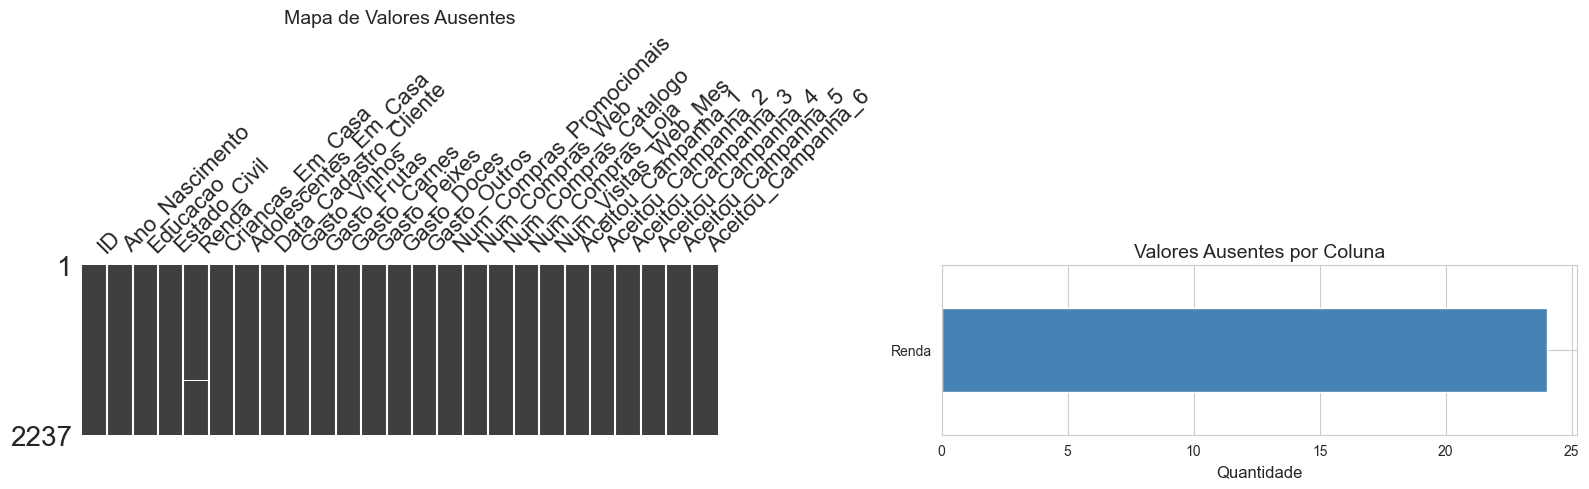


Total de valores ausentes por coluna:
Renda    24
dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Matriz visual de valores ausentes
msno.matrix(df, ax=axes[0], sparkline=False)
axes[0].set_title('Mapa de Valores Ausentes')

# Contagem de valores ausentes por coluna (apenas colunas com ausentes)
ausentes = df.isnull().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=True)
ausentes.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Valores Ausentes por Coluna')
axes[1].set_xlabel('Quantidade')

plt.tight_layout()
plt.show()

print("\nTotal de valores ausentes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

### 3.3 Detecção e Remoção de Outliers na Variável `Renda`

Antes de imputar os valores ausentes, verificamos a presença de outliers em `Renda`, pois eles podem distorcer a imputação por vizinhança (KNN). Utilizamos o método **IQR (Intervalo Interquartil)**.

Q1: 35,246 | Q3: 68,487 | IQR: 33,241
Limite inferior: -14,616 | Limite superior: 118,348
Outliers identificados: 8

Registros após remoção de outliers: 2205


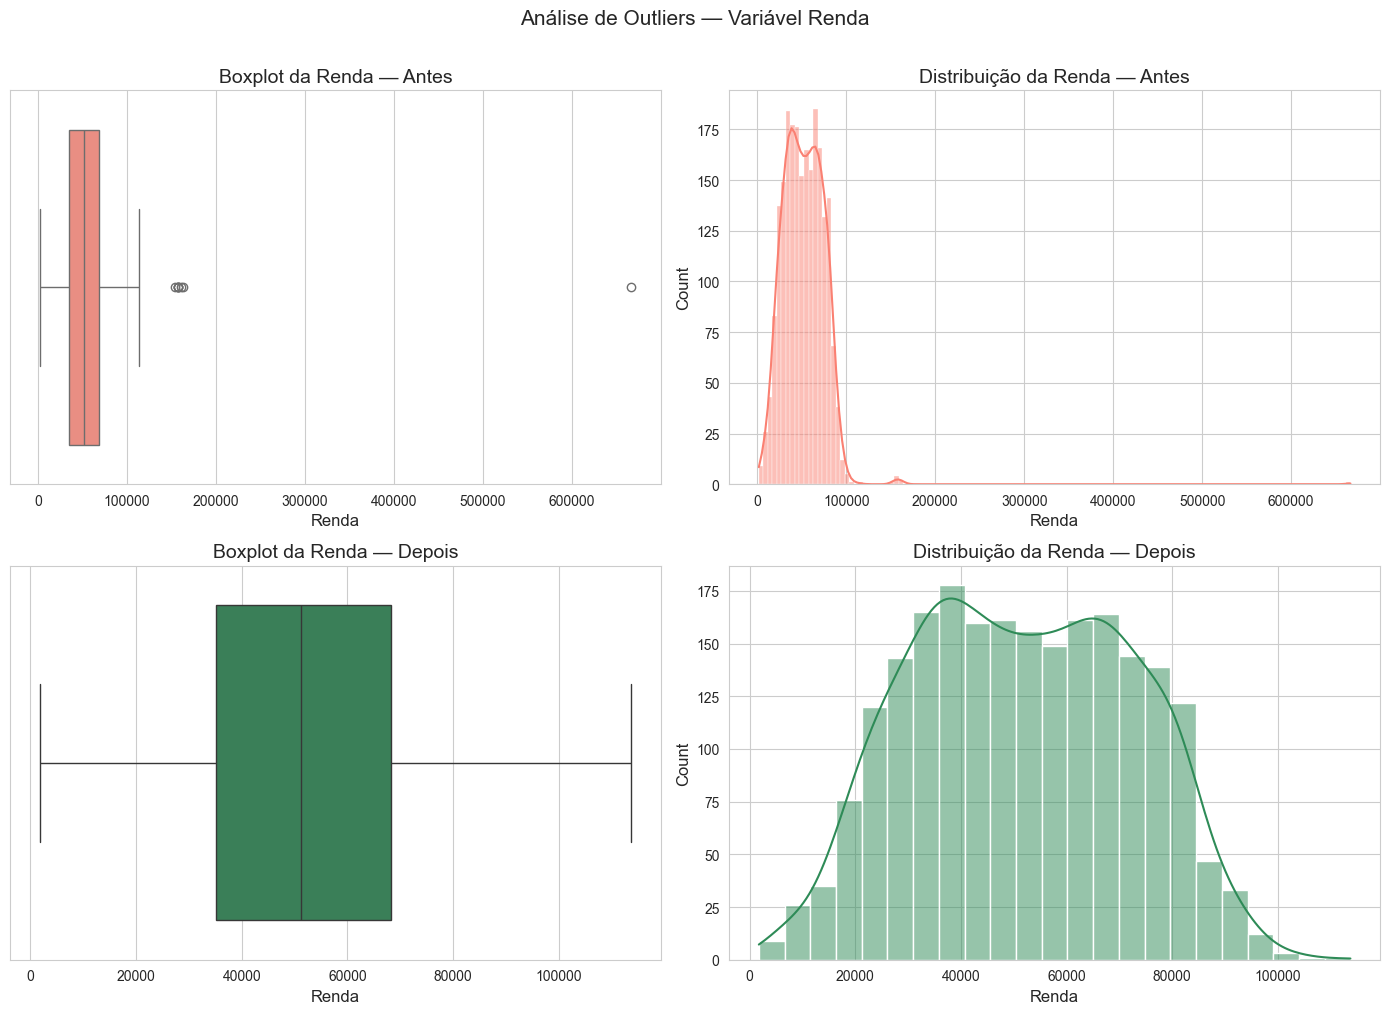

In [7]:
# Calcular limites pelo método IQR
Q1 = df['Renda'].quantile(0.25)
Q3 = df['Renda'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = ((df['Renda'] < lower_bound) | (df['Renda'] > upper_bound)).sum()
print(f"Q1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"Limite inferior: {lower_bound:,.0f} | Limite superior: {upper_bound:,.0f}")
print(f"Outliers identificados: {n_outliers}")

# Visualização antes e depois da remoção
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x=df['Renda'], ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Boxplot da Renda — Antes')

sns.histplot(df['Renda'], kde=True, color='salmon', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição da Renda — Antes')

# Remover outliers
df = df[(df['Renda'] >= lower_bound) & (df['Renda'] <= upper_bound)].copy()
print(f"\nRegistros após remoção de outliers: {len(df)}")

sns.boxplot(x=df['Renda'], ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Boxplot da Renda — Depois')

sns.histplot(df['Renda'], kde=True, color='seagreen', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição da Renda — Depois')

plt.suptitle('Análise de Outliers — Variável Renda', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Imputação de Valores Ausentes com KNN

Como a variável `Renda` ainda possui valores ausentes após a remoção de outliers, utilizamos o **KNN Imputer** (k = 5 vizinhos). Essa abordagem preserva melhor a estrutura dos dados do que a simples substituição pela média ou mediana. Os dados são normalizados antes da imputação e revertidos ao final.

In [8]:
# Normalizar a variável antes da imputação
scaler = StandardScaler()
renda_scaled = scaler.fit_transform(df[['Renda']])

# Aplicar KNN Imputer
imputer = KNNImputer(n_neighbors=5)
renda_imputed = imputer.fit_transform(renda_scaled)

# Reverter normalização e atualizar o DataFrame
df['Renda'] = scaler.inverse_transform(renda_imputed)

print(f"Valores ausentes restantes: {df.isnull().sum().sum()}")

Valores ausentes restantes: 0


---
## 4. Engenharia de Features

Criação de variáveis derivadas para enriquecer a análise.

In [9]:
# Idade do cliente (baseada no ano atual)
ano_atual = datetime.now().year
df['Idade'] = ano_atual - df['Ano_Nascimento']

# Tempo de relacionamento em dias desde o cadastro
df['Dias_Como_Cliente'] = (
    df['Data_Cadastro_Cliente'].max() - df['Data_Cadastro_Cliente']
).dt.days

# Total de compras nos três canais
df['TotalCompras'] = (
    df['Num_Compras_Web'] + df['Num_Compras_Catalogo'] + df['Num_Compras_Loja']
)

# Gasto total em todas as categorias de produto
df['Gasto_Total'] = df.filter(like='Gasto').sum(axis=1)

# Variável-alvo: indica se o cliente aceitou ao menos uma campanha
aceitou_cols = [c for c in df.columns if c.startswith('Aceitou')]
df['RespostaCampanha'] = (
    df[aceitou_cols].sum(axis=1)
    .apply(lambda x: 'Aceitou' if x > 0 else 'Não Aceitou')
)

# Remover colunas originais que deram origem às features derivadas
df.drop(columns=['Ano_Nascimento', 'Data_Cadastro_Cliente'], inplace=True)

print("Features do dataset após engenharia:")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")

Features do dataset após engenharia:
['ID', 'Educacao', 'Estado_Civil', 'Renda', 'Criancas_Em_Casa', 'Adolescentes_Em_Casa', 'Gasto_Vinhos', 'Gasto_Frutas', 'Gasto_Carnes', 'Gasto_Peixes', 'Gasto_Doces', 'Gasto_Outros', 'Num_Compras_Promocionais', 'Num_Compras_Web', 'Num_Compras_Catalogo', 'Num_Compras_Loja', 'Num_Visitas_Web_Mes', 'Aceitou_Campanha_1', 'Aceitou_Campanha_2', 'Aceitou_Campanha_3', 'Aceitou_Campanha_4', 'Aceitou_Campanha_5', 'Aceitou_Campanha_6', 'Idade', 'Dias_Como_Cliente', 'TotalCompras', 'Gasto_Total', 'RespostaCampanha']

Shape: (2205, 28)


In [10]:
print("=== Amostra Aleatória ===")
display(df.sample(5, random_state=42))

print("\n=== Estatísticas Descritivas ===")
df.describe().T.style.background_gradient(cmap='Blues')

=== Amostra Aleatória ===


,ID,Educacao,Estado_Civil,Renda,Criancas_Em_Casa,Adolescentes_Em_Casa,Gasto_Vinhos,Gasto_Frutas,Gasto_Carnes,Gasto_Peixes,...,Aceitou_Campanha_2,Aceitou_Campanha_3,Aceitou_Campanha_4,Aceitou_Campanha_5,Aceitou_Campanha_6,Idade,Dias_Como_Cliente,TotalCompras,Gasto_Total,RespostaCampanha
1994,4351,Graduação,Divorciado,37244.0,1,1,18,2,10,0,...,0,0,0,0,0,71,428,4,55,Aceitou
1105,4550,Mestrado,Casado,33564.0,0,1,61,0,3,0,...,0,0,0,0,0,60,5,5,71,Não Aceitou
1486,3422,Graduação,Casado,76068.0,0,1,1115,12,128,33,...,1,0,0,1,0,51,577,9,1376,Aceitou
442,2139,Mestrado,Casado,7500.0,1,0,3,1,10,3,...,0,0,0,0,0,51,1597,5,31,Não Aceitou
1812,8397,Graduação,Casado,44689.0,1,1,18,0,5,0,...,0,0,0,0,0,75,4641,4,34,Aceitou



=== Estatísticas Descritivas ===


,count,mean,std,min,25%,50%,75%,max
ID,2205.000000,5585.439456,3247.546423,0.000000,2815.000000,5455.000000,8418.000000,11191.000000
Renda,2205.000000,51622.094785,20713.063826,1730.000000,35196.000000,51287.000000,68281.000000,113734.000000
Criancas_Em_Casa,2205.000000,0.442177,0.537132,0.000000,0.000000,0.000000,1.000000,2.000000
Adolescentes_Em_Casa,2205.000000,0.506576,0.544380,0.000000,0.000000,0.000000,1.000000,2.000000
Gasto_Vinhos,2205.000000,306.164626,337.493839,0.000000,24.000000,178.000000,507.000000,1493.000000
Gasto_Frutas,2205.000000,26.403175,39.784484,0.000000,2.000000,8.000000,33.000000,199.000000
Gasto_Carnes,2205.000000,165.312018,217.784507,0.000000,16.000000,68.000000,232.000000,1725.000000
Gasto_Peixes,2205.000000,37.756463,54.824635,0.000000,3.000000,12.000000,50.000000,259.000000
Gasto_Doces,2205.000000,27.128345,41.130468,0.000000,1.000000,8.000000,34.000000,262.000000
Gasto_Outros,2205.000000,44.057143,51.736211,0.000000,9.000000,25.000000,56.000000,321.000000


---
## 5. Visão Geral da Distribuição dos Dados

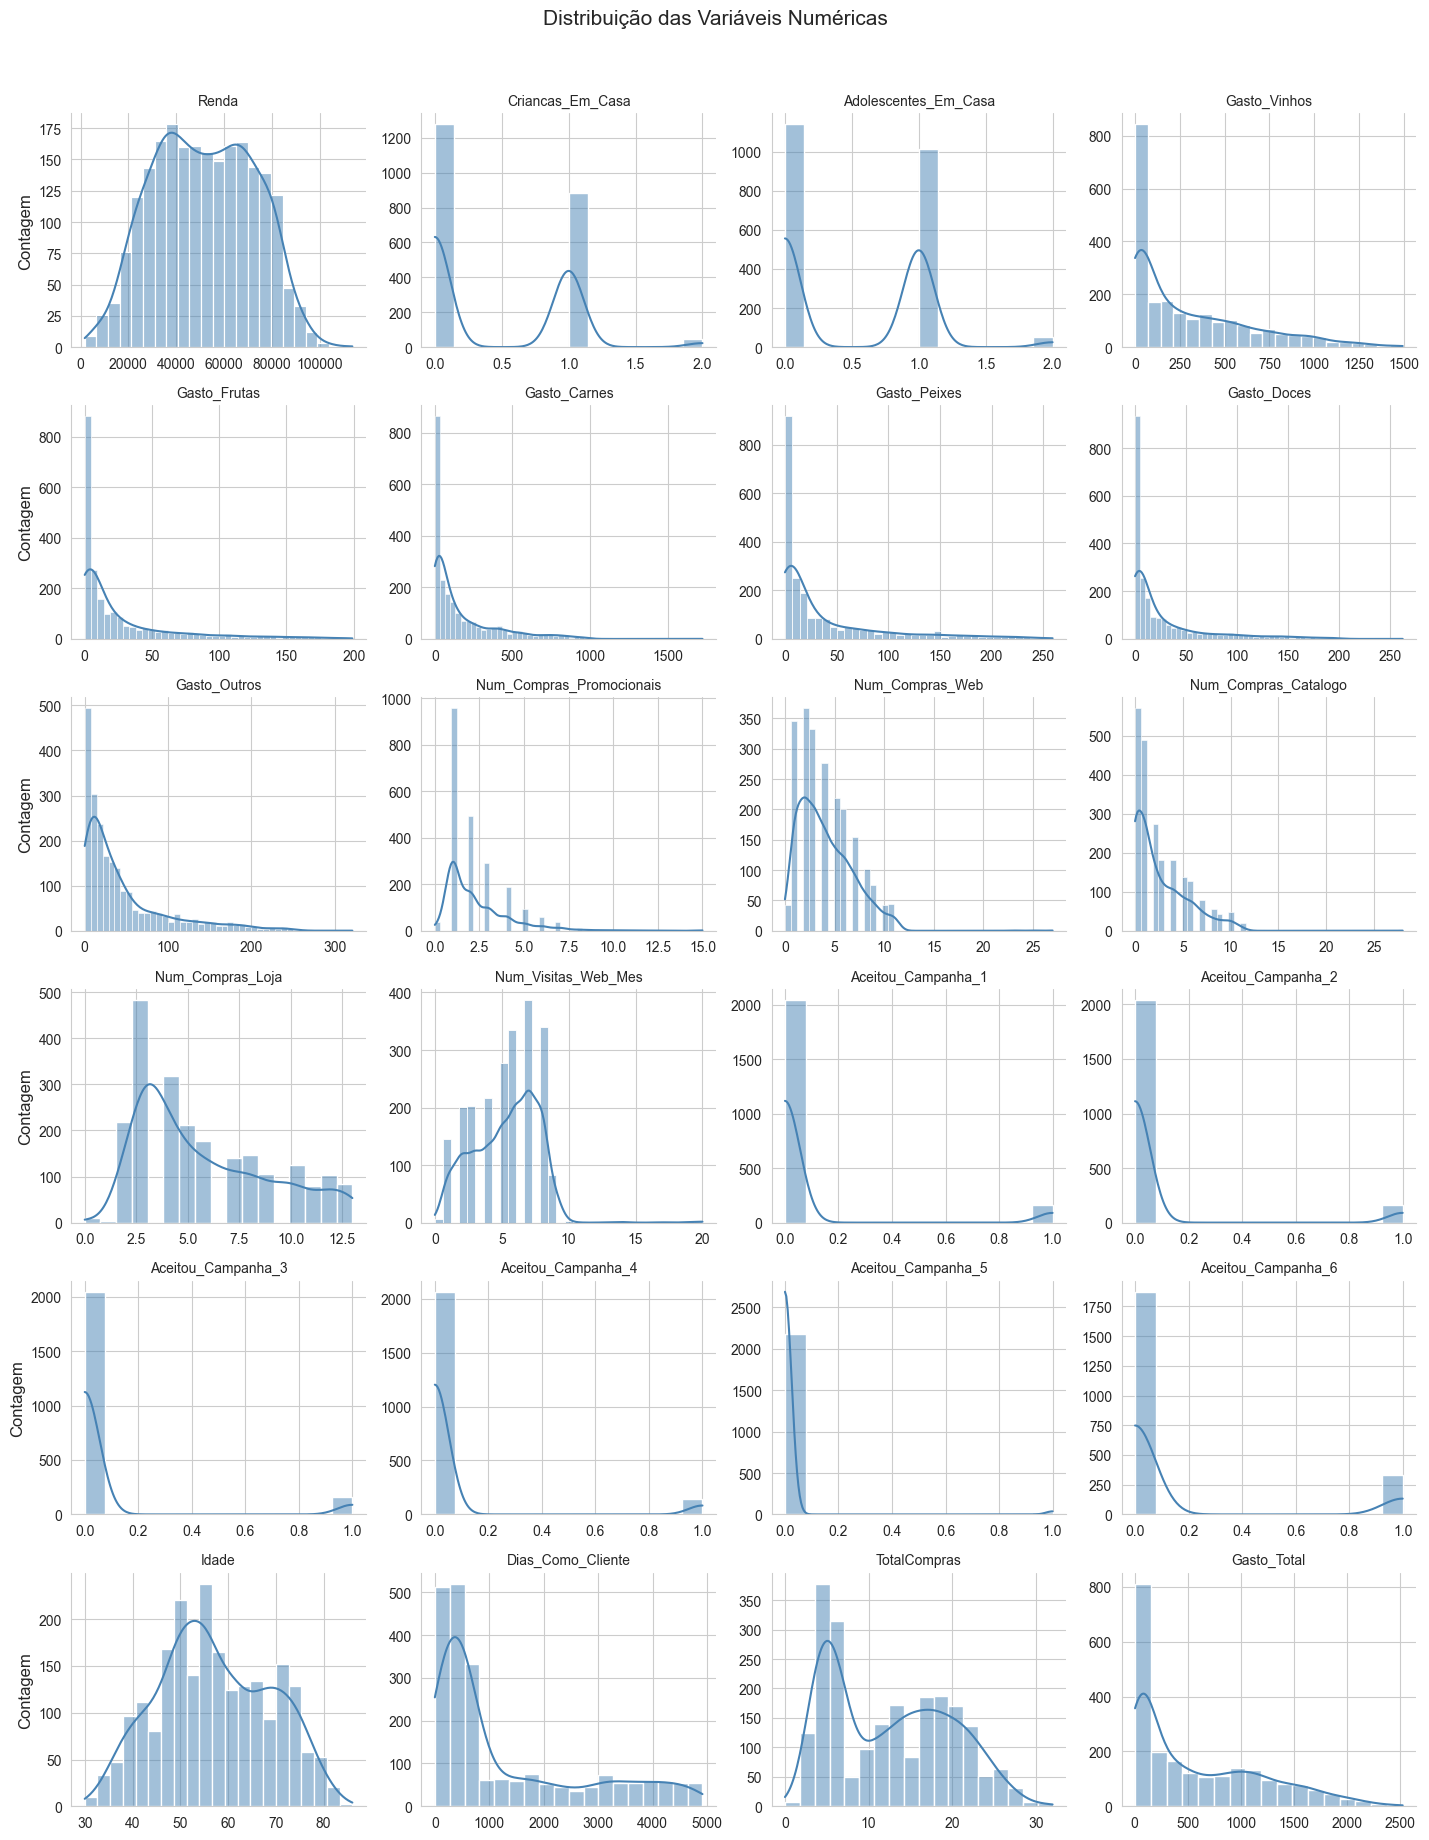

In [11]:
# Histogramas de todas as variáveis numéricas
numeric_vars = df.select_dtypes(include='number').columns.drop('ID').tolist()
melt_df = pd.melt(df[numeric_vars], var_name='Variável', value_name='Valor')

g = sns.FacetGrid(
    melt_df, col='Variável', col_wrap=4,
    sharex=False, sharey=False, height=3, aspect=1.2
)
g.map(sns.histplot, 'Valor', kde=True, color='steelblue')
g.set_titles(col_template='{col_name}', size=10)
g.set_axis_labels('', 'Contagem')
plt.suptitle('Distribuição das Variáveis Numéricas', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

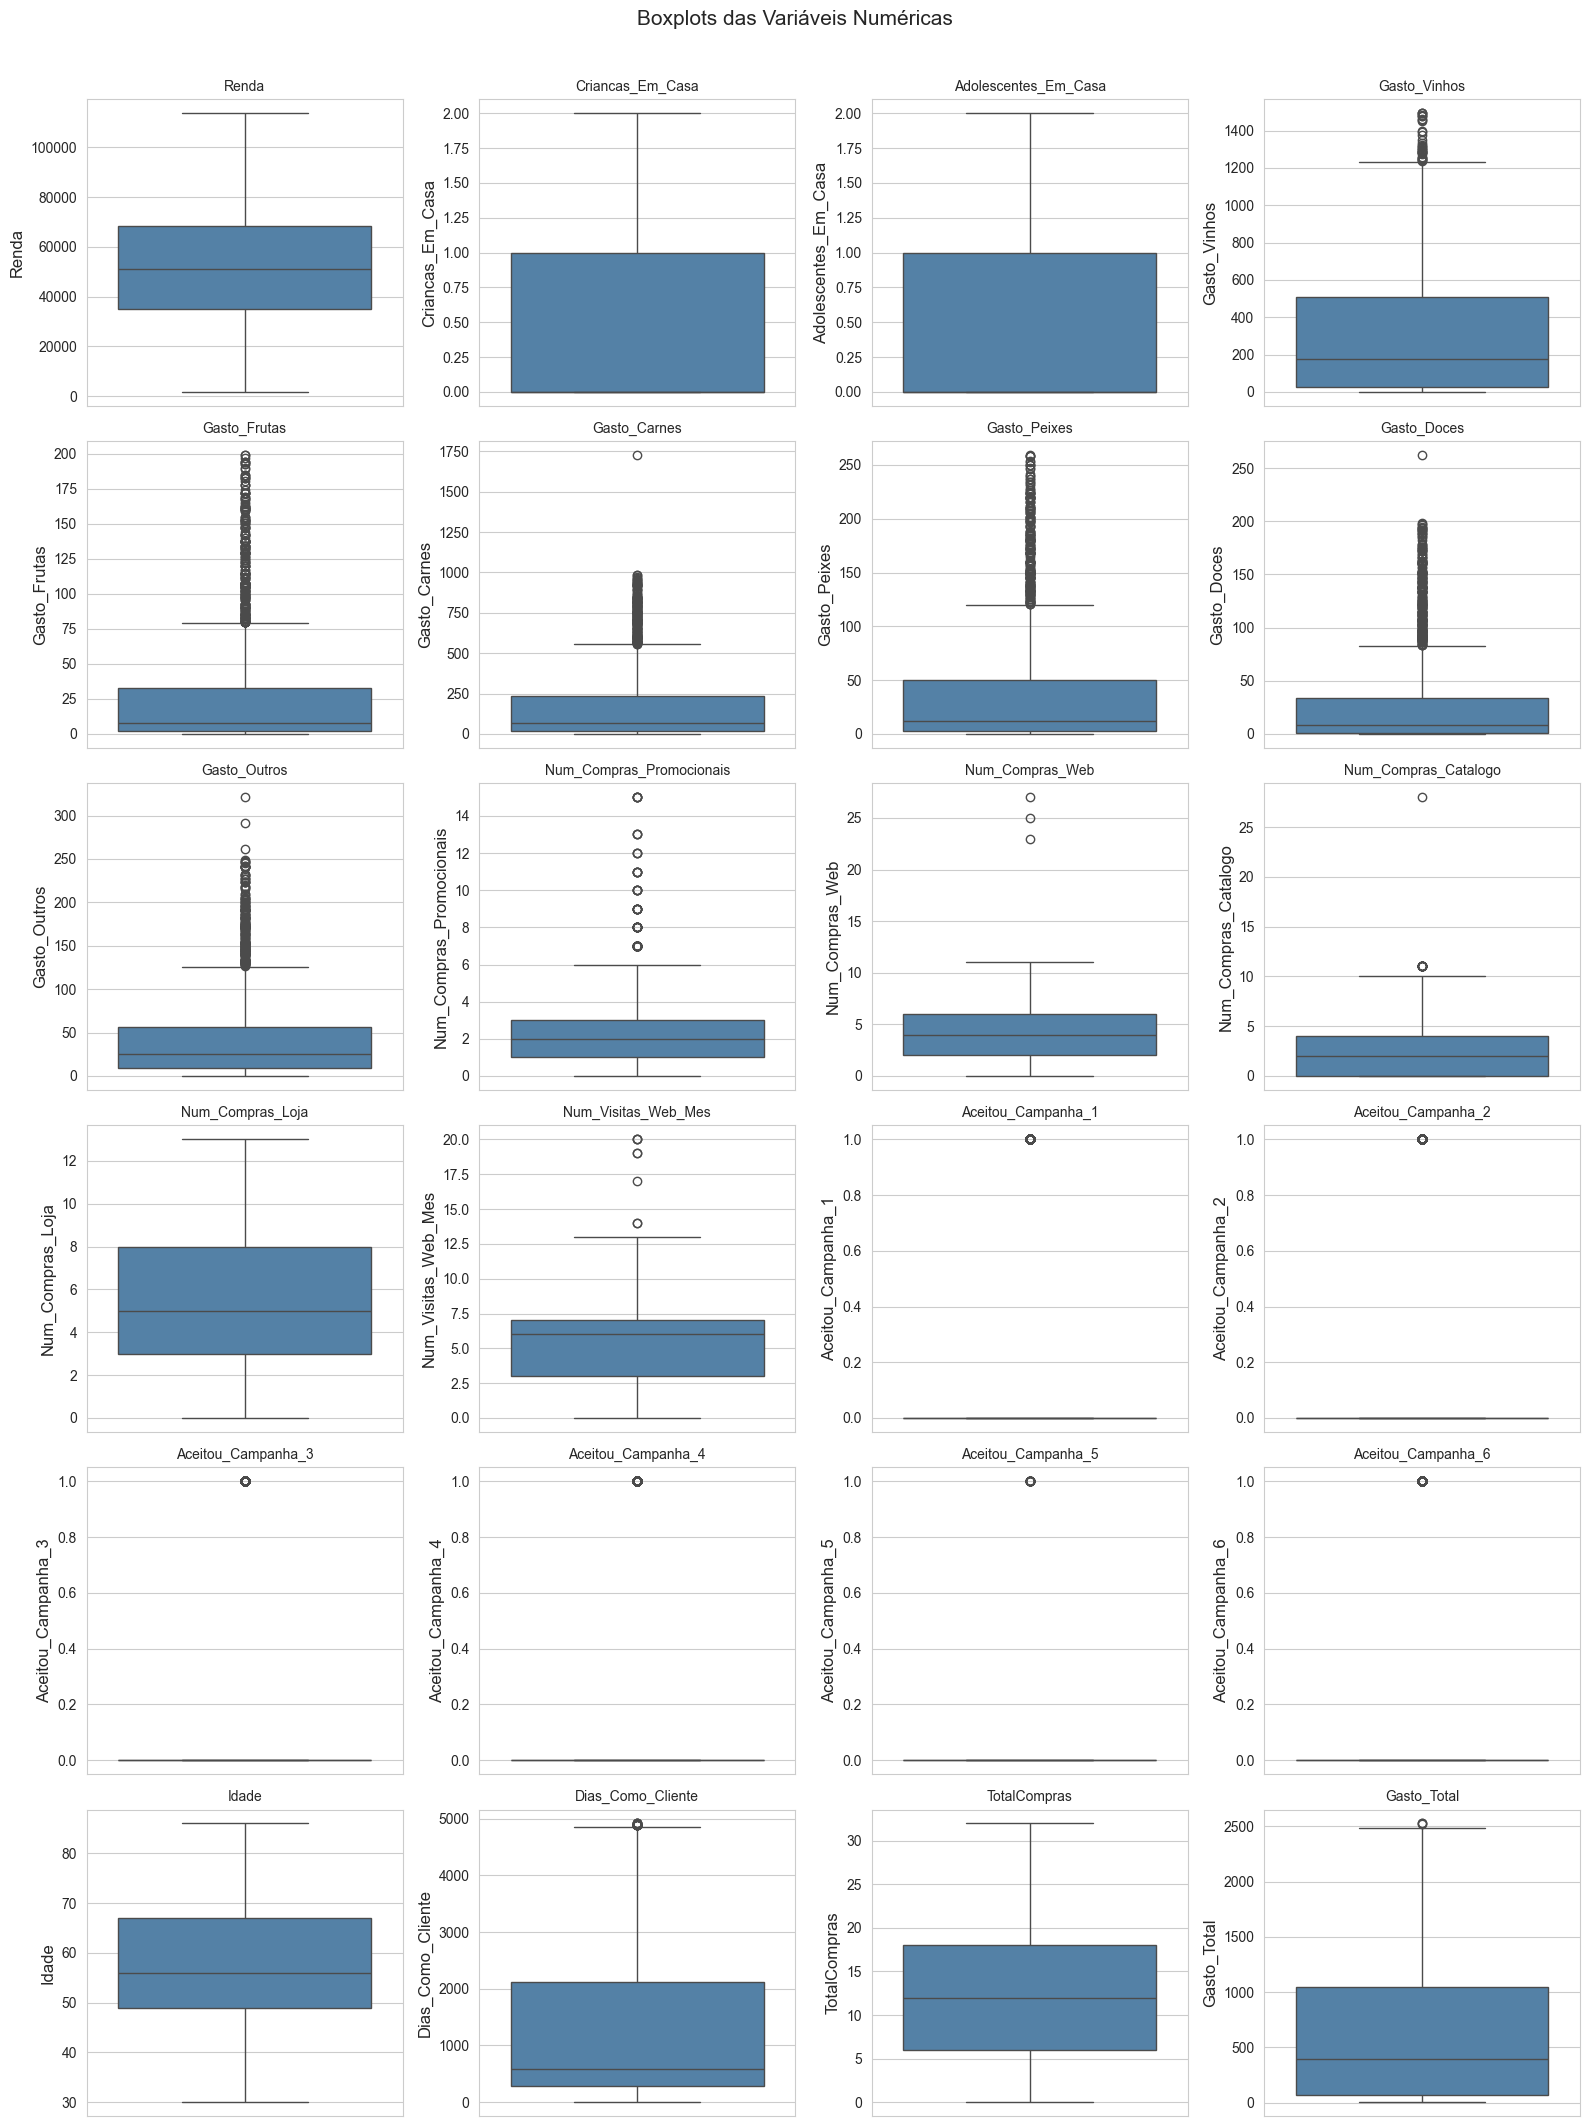

In [12]:
# Boxplots de todas as variáveis numéricas
n_cols = len(numeric_vars)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots das Variáveis Numéricas', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Análise Exploratória — Perguntas de Negócio

### 6.1 Qual a Proporção de Clientes que Aceitaram/Não Aceitaram Campanhas?

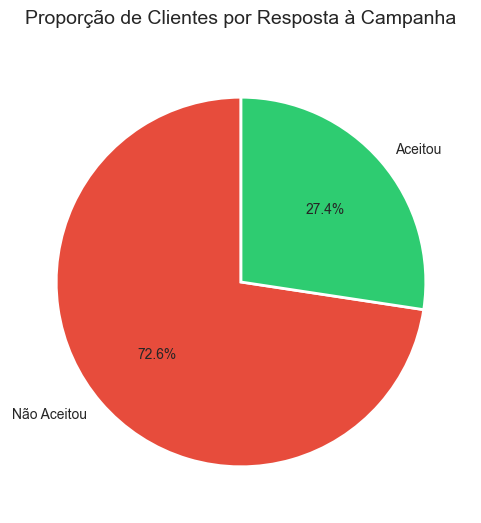

In [26]:
counts = df['RespostaCampanha'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    counts,
    labels=counts.index,
    colors=['#E74C3C','#2ECC71'],
    autopct='%.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Proporção de Clientes por Resposta à Campanha', fontsize=14, pad=20)
plt.show()

### 6.2 Qual a Taxa de Sucesso de Cada Uma das 6 Campanhas?

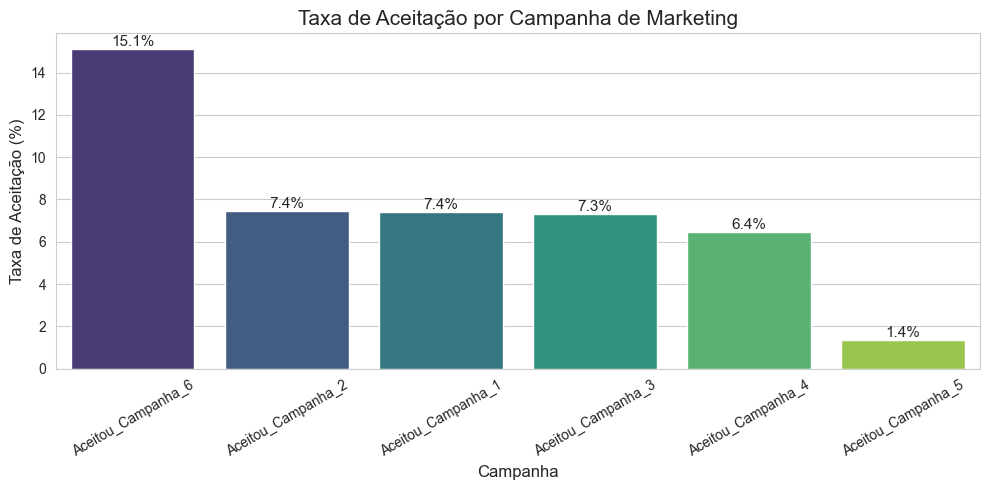

In [14]:
aceitou_cols = [c for c in df.columns if c.startswith('Aceitou')]
taxa_sucesso = (df[aceitou_cols].mean() * 100).reset_index()
taxa_sucesso.columns = ['Campanha', 'Taxa (%)']
taxa_sucesso = taxa_sucesso.sort_values('Taxa (%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='Campanha', y='Taxa (%)', data=taxa_sucesso, palette='viridis', ax=ax)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Taxa de Aceitação por Campanha de Marketing', fontsize=15)
ax.set_xlabel('Campanha', fontsize=12)
ax.set_ylabel('Taxa de Aceitação (%)', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6.3 A Idade Tem Influência nos Gastos dos Clientes?

Calculamos a correlação de Pearson entre `Idade` e as demais variáveis numéricas para identificar relações lineares.

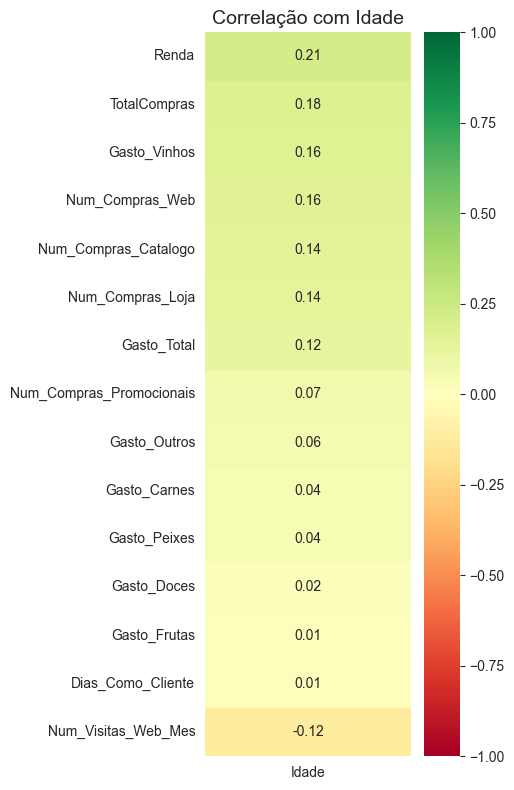

In [15]:
drop_cols = (
    ['ID', 'Educacao', 'Estado_Civil', 'Criancas_Em_Casa',
     'Adolescentes_Em_Casa', 'RespostaCampanha'] +
    [c for c in df.columns if c.startswith('Aceitou')]
)
df_corr = df.drop(columns=drop_cols).corr()

correlacao_idade = df_corr['Idade'].drop('Idade').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5, 8))
sns.heatmap(
    pd.DataFrame(correlacao_idade),
    annot=True,
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    fmt='.2f',
    ax=ax
)
ax.set_title('Correlação com Idade', fontsize=14)
plt.tight_layout()
plt.show()

### 6.4 Qual a Relação entre Gasto Total e Resposta às Campanhas?

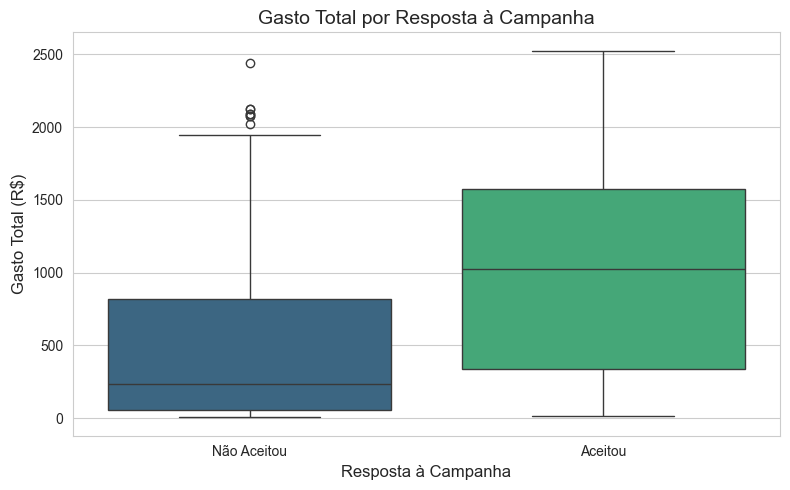

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='RespostaCampanha', y='Gasto_Total', data=df, palette='viridis', ax=ax)
ax.set_title('Gasto Total por Resposta à Campanha', fontsize=14)
ax.set_xlabel('Resposta à Campanha', fontsize=12)
ax.set_ylabel('Gasto Total (R$)', fontsize=12)
plt.tight_layout()
plt.show()

### 6.5 Em Qual Categoria de Produto os Clientes Têm Maior Gasto?

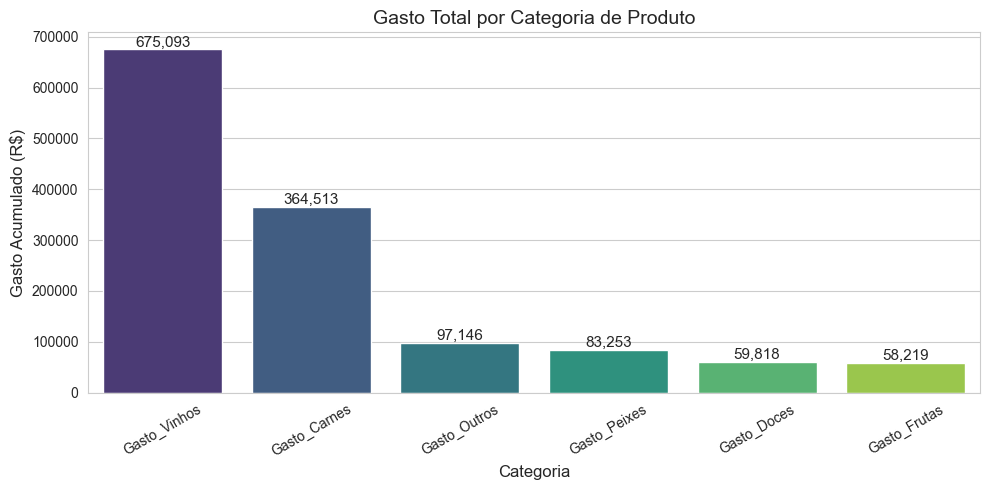

In [17]:
gasto_cols = [c for c in df.columns if c.startswith('Gasto_') and c != 'Gasto_Total']
df_produtos = pd.DataFrame(df[gasto_cols].sum(), columns=['Total']).reset_index()
df_produtos.columns = ['Produto', 'Total']
df_produtos = df_produtos.sort_values('Total', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='Produto', y='Total', data=df_produtos, palette='viridis', ax=ax)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Gasto Total por Categoria de Produto', fontsize=14)
ax.set_xlabel('Categoria', fontsize=12)
ax.set_ylabel('Gasto Acumulado (R$)', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6.6 Qual a Relação entre Gasto com Vinho e Resposta às Campanhas?

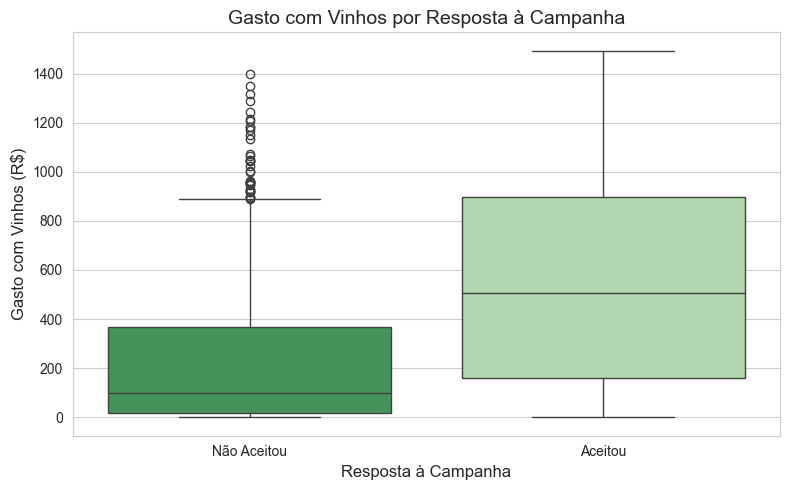

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='RespostaCampanha', y='Gasto_Vinhos', data=df, palette='Greens_r', ax=ax)
ax.set_title('Gasto com Vinhos por Resposta à Campanha', fontsize=14)
ax.set_xlabel('Resposta à Campanha', fontsize=12)
ax.set_ylabel('Gasto com Vinhos (R$)', fontsize=12)
plt.tight_layout()
plt.show()

### 6.7 Qual a Relação entre Renda e Resposta às Campanhas?

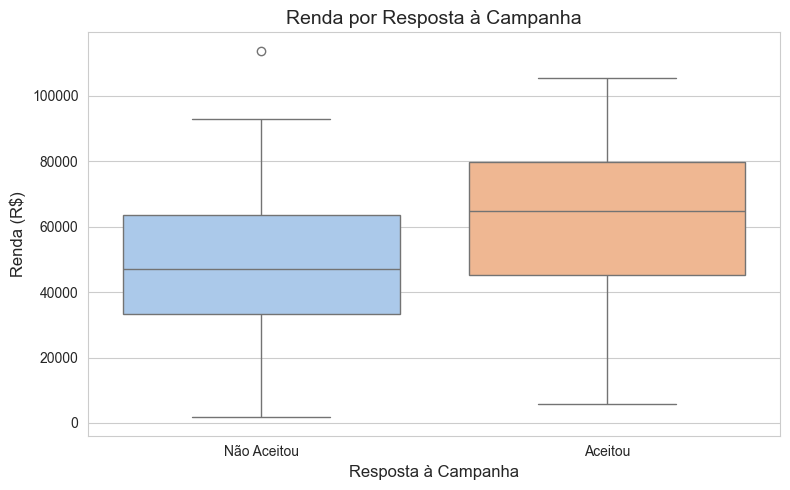

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='RespostaCampanha', y='Renda', data=df, palette='pastel', ax=ax)
ax.set_title('Renda por Resposta à Campanha', fontsize=14)
ax.set_xlabel('Resposta à Campanha', fontsize=12)
ax.set_ylabel('Renda (R$)', fontsize=12)
plt.tight_layout()
plt.show()

### 6.8 Qual a Relação entre Renda e Gasto Total?

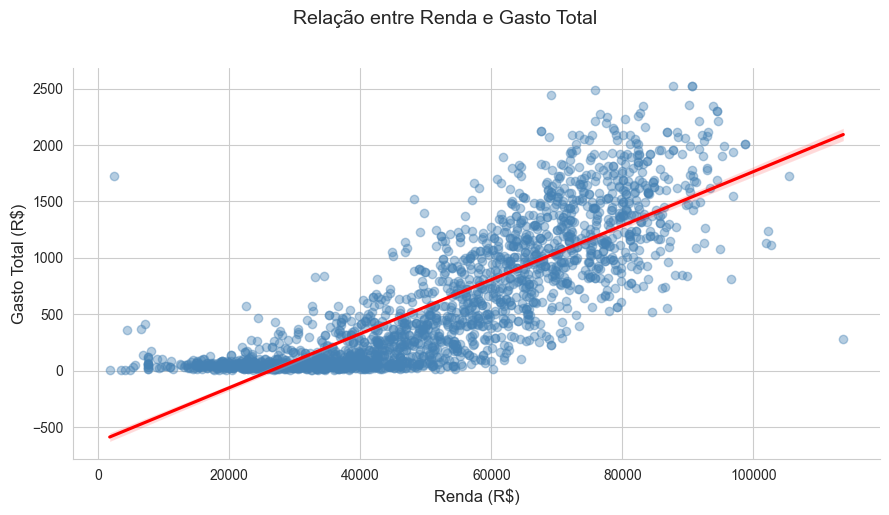

In [20]:
g = sns.lmplot(
    x='Renda', y='Gasto_Total', data=df,
    scatter_kws={'color': 'steelblue', 'alpha': 0.4},
    line_kws={'color': 'red'},
    height=5, aspect=1.8
)
g.set_axis_labels('Renda (R$)', 'Gasto Total (R$)')
g.figure.suptitle('Relação entre Renda e Gasto Total', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. Importância das Features com Random Forest

Para identificar os fatores mais determinantes na decisão do cliente de aceitar ou não uma campanha, treinamos um modelo de **Random Forest** e extraímos a importância relativa de cada variável. Features com maior importância explicam melhor a variação na variável-alvo.

In [21]:
# Codificar variáveis categóricas com One-Hot Encoding
df_imp = pd.get_dummies(df, columns=['Educacao', 'Estado_Civil'])

# Colunas a remover de X:
#   - ID (identificador)
#   - RespostaCampanha (alvo, y)
#   - Gastos individuais (já resumidos em Gasto_Total)
#   - Compras por canal individuais (já resumidas em TotalCompras)
#   - Variáveis de campanha individuais (já resumidas em RespostaCampanha)
cols_remover = (
    ['ID', 'RespostaCampanha',
     'Gasto_Vinhos', 'Gasto_Frutas', 'Gasto_Carnes',
     'Gasto_Peixes', 'Gasto_Doces', 'Gasto_Outros',
     'Num_Compras_Web', 'Num_Compras_Catalogo', 'Num_Compras_Loja'] +
    [c for c in df_imp.columns if c.startswith('Aceitou')]
)

X = df_imp.drop(columns=cols_remover)
y = df_imp['RespostaCampanha'].map({'Não Aceitou': 0, 'Aceitou': 1})

# Treinar Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X, y)

print(f"Modelo treinado | Features: {X.shape[1]} | Amostras: {X.shape[0]}")

Modelo treinado | Features: 18 | Amostras: 2205


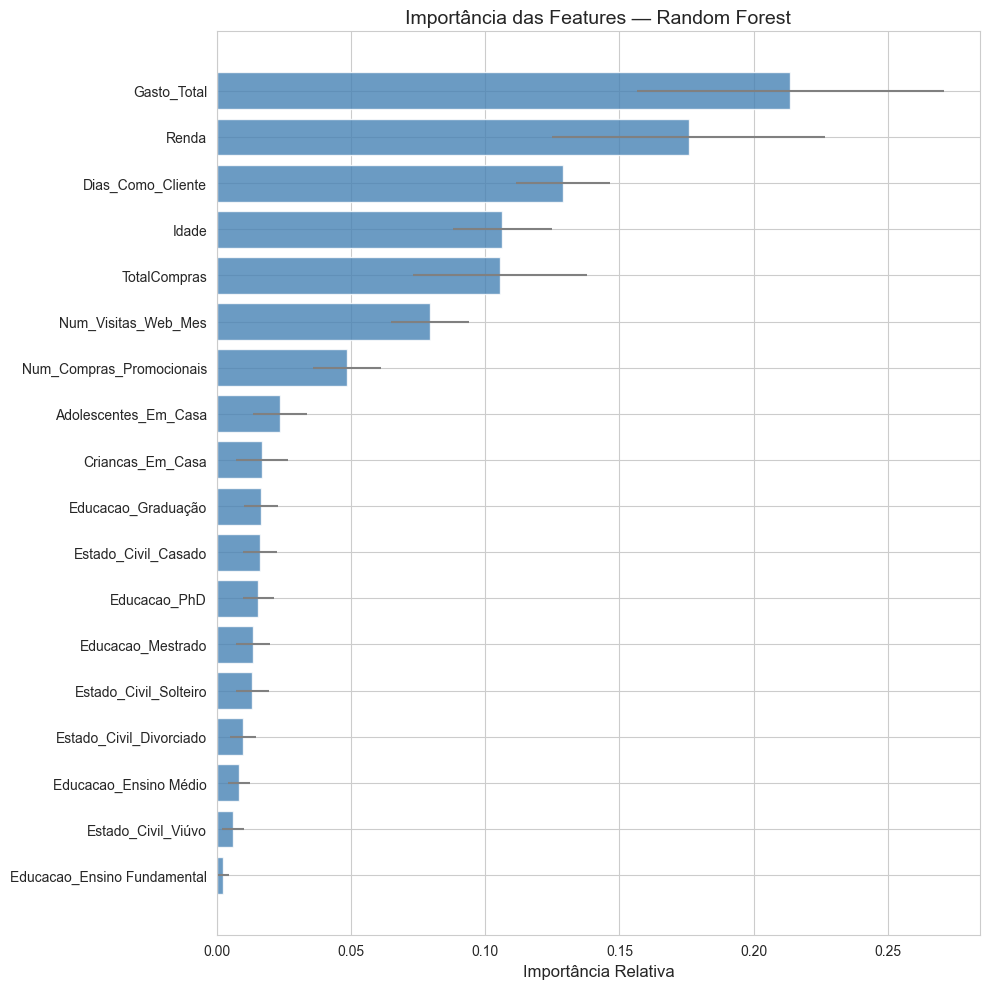

In [22]:
importances = modelo_rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in modelo_rf.estimators_], axis=0)
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(
    range(X.shape[1]), importances[indices],
    xerr=std[indices], align='center',
    color='steelblue', alpha=0.8, ecolor='gray'
)
ax.set_yticks(range(X.shape[1]))
ax.set_yticklabels(X.columns[indices], fontsize=10)
ax.set_xlabel('Importância Relativa', fontsize=12)
ax.set_title('Importância das Features — Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

---
## 8. Teste de Hipóteses — Renda e Nível Educacional

A análise de importância das features sugere que o nível educacional tem baixa influência direta sobre a aceitação de campanhas. No entanto, a renda é altamente relevante e pode estar correlacionada com o nível educacional.

**Pergunta:** Existe diferença significativa na renda média entre clientes **com** e **sem** nível superior?

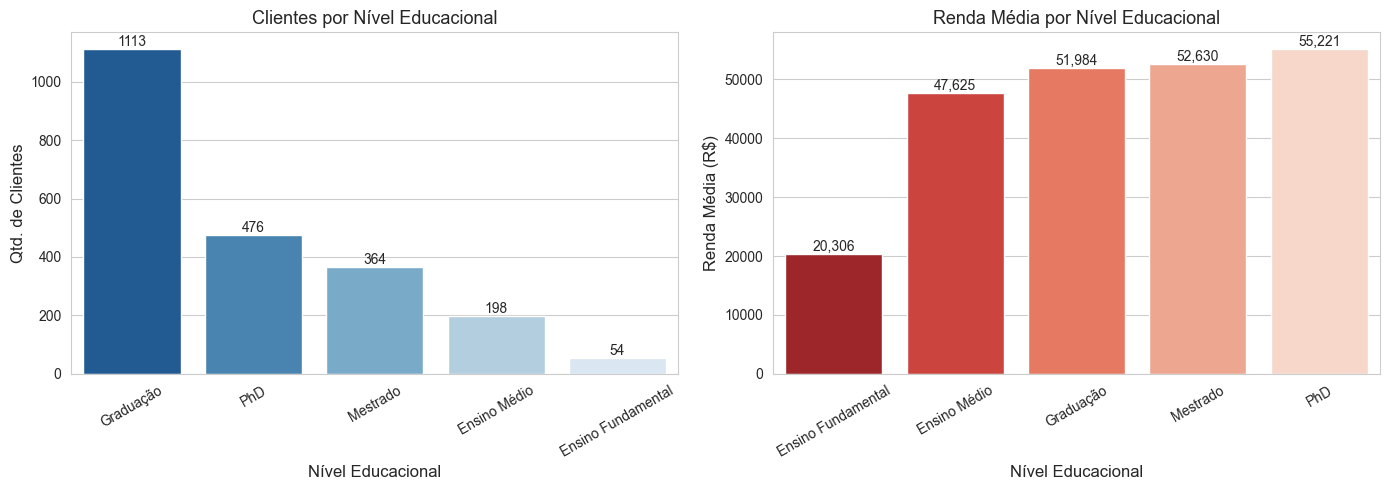

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem de clientes por nível educacional
contagem = df['Educacao'].value_counts().sort_values(ascending=False)
sns.barplot(x=contagem.index, y=contagem.values, palette='Blues_r', ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )
axes[0].set_title('Clientes por Nível Educacional', fontsize=13)
axes[0].set_xlabel('Nível Educacional')
axes[0].set_ylabel('Qtd. de Clientes')
axes[0].tick_params(axis='x', rotation=30)

# Renda média por nível educacional
media_renda = df.groupby('Educacao')['Renda'].mean().sort_values()
sns.barplot(x=media_renda.index, y=media_renda.values, palette='Reds_r', ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )
axes[1].set_title('Renda Média por Nível Educacional', fontsize=13)
axes[1].set_xlabel('Nível Educacional')
axes[1].set_ylabel('Renda Média (R$)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 8.1 Definição das Hipóteses

- **H₀ (Hipótese Nula):** Não há diferença significativa na renda média entre clientes com e sem nível superior. Qualquer diferença observada é atribuída ao acaso.
- **H₁ (Hipótese Alternativa):** Há diferença significativa na renda média entre clientes com e sem nível superior.

**Critério de decisão:**
- **p-valor < 0,05** → rejeita-se H₀: a diferença é estatisticamente significativa.
- **p-valor ≥ 0,05** → não se rejeita H₀: não há evidência suficiente de diferença.

### 8.2 Teste de Normalidade (Shapiro-Wilk)

Antes de escolher o teste de hipóteses, verificamos se as variáveis seguem distribuição normal. O **Teste de Shapiro-Wilk** é adequado para essa finalidade, especialmente em amostras de tamanho moderado.

- **H₀:** Os dados seguem distribuição normal.
- **H₁:** Os dados não seguem distribuição normal.

In [24]:
# Codificar Educacao numericamente para o teste estatístico
mapa_educacao = {
    'Ensino Fundamental': 1,
    'Ensino Médio': 2,
    'Graduação': 3,
    'Mestrado': 4,
    'PhD': 5
}
df['Educacao_Num'] = df['Educacao'].map(mapa_educacao)

alpha = 0.05
print(f"Nível de significância: α = {alpha}\n")
print(f"{'Variável':<20} {'Estatística':>12} {'p-valor':>12}  Resultado")
print("-" * 70)

for col in ['Renda', 'Educacao_Num']:
    stat, p_value = shapiro(df[col].dropna())
    resultado = "Rejeitar H₀ → dados NÃO normais" if p_value < alpha else "Não rejeitar H₀ → dados normais"
    print(f"{col:<20} {stat:>12.4f} {p_value:>12.4f}  {resultado}")

Nível de significância: α = 0.05

Variável              Estatística      p-valor  Resultado
----------------------------------------------------------------------
Renda                      0.9845       0.0000  Rejeitar H₀ → dados NÃO normais
Educacao_Num               0.8493       0.0000  Rejeitar H₀ → dados NÃO normais


### 8.3 Teste Não Paramétrico — Mann-Whitney U

Como os dados **não seguem distribuição normal** (p-valor < 0,05 no Shapiro-Wilk), aplicamos o **Teste de Mann-Whitney U**, alternativa não paramétrica ao teste t de Student para dois grupos independentes. Ele compara se as distribuições das duas amostras são estatisticamente equivalentes, sem exigir normalidade.

In [25]:
# Separar grupos: com nível superior (Graduação, Mestrado, PhD) vs. sem (Fund., Médio)
grupo_com_superior = df[df['Educacao_Num'] >= 3]['Renda']
grupo_sem_superior = df[df['Educacao_Num'] < 3]['Renda']

print(f"Clientes com nível superior (Grad/Mestrado/PhD): {len(grupo_com_superior)}")
print(f"Clientes sem nível superior (Fund./Médio):       {len(grupo_sem_superior)}")

# Aplicar Teste de Mann-Whitney U
stat, p_value = mannwhitneyu(grupo_com_superior, grupo_sem_superior)

print(f"\nEstatística U : {stat:.2f}")
print(f"p-valor       : {p_value:.6f}")
print(f"Nível α       : {alpha}")

if p_value < alpha:
    print("\nResultado: Rejeitamos H₀.")
    print("Há diferença significativa na renda média entre clientes com e sem nível superior.")
else:
    print("\nResultado: Falhamos em rejeitar H₀.")
    print("Não há evidência de diferença significativa na renda média entre os grupos.")

Clientes com nível superior (Grad/Mestrado/PhD): 1953
Clientes sem nível superior (Fund./Médio):       252

Estatística U : 320508.50
p-valor       : 0.000000
Nível α       : 0.05

Resultado: Rejeitamos H₀.
Há diferença significativa na renda média entre clientes com e sem nível superior.


---
## 9. Conclusão

### Principais Descobertas

| Fator | Relevância para Aceitação de Campanha |
|---|---|
| **Gasto Total** | Alta — clientes que aceitam campanhas possuem histórico de gasto significativamente maior |
| **Renda** | Alta — renda mais elevada está associada à aceitação de campanhas |
| **Dias como Cliente** | Alta — clientes mais antigos respondem melhor às campanhas |
| **Total de Compras** | Moderada — histórico de compras é um bom preditor |
| **Idade** | Moderada — possui correlação com gastos, mas fraca com campanhas |
| **Nível Educacional** | Baixa direta, porém correlacionada com renda |

### Recomendações Estratégicas

1. **Segmentar por renda e histórico de gastos:** clientes com maior poder de compra e engajamento anterior são os mais propensos a aceitar campanhas.
2. **Priorizar clientes de longa data:** fidelidade está diretamente associada à maior conversão em campanhas.
3. **Referenciar as Campanhas 5 e 1** como modelos de sucesso para futuras estratégias, por apresentarem as maiores taxas de aceitação.
4. **Personalizar por nível educacional indiretamente:** embora não seja um preditor direto, está correlacionado com a renda — que é um forte driver de conversão.
5. **Investir em produtos premium como Vinho e Carnes**, categorias com maior gasto total e que discriminam melhor aceitantes de não aceitantes.

### Nota Estatística

O **Teste de Mann-Whitney U** confirmou diferença estatisticamente significativa (p-valor < 0,05) na renda entre clientes com e sem nível superior, reforçando que estratégias de segmentação por nível educacional indiretamente atingem segmentos de maior renda — e maior potencial de conversão.